In [1]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from datetime import datetime

In [2]:
# force 'normal' text style for math text
mpl.rcParams['mathtext.default'] = 'regular'

# set global seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [4]:
ts = pd.read_csv('MOD-00686-2-19data.csv')
COLS_TO_INCLUDE = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','pm25','co','o3','no','no2','rh','temp']
ts = ts[COLS_TO_INCLUDE]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-30T04:53:24Z,1.396,0.156,0.045,0.017,0.024,0.024,0.895,638.233,32.602,1.582,30.536,41.7,0.6
1,2025-12-30T04:52:24Z,1.545,0.137,0.067,0.013,0.029,0.025,0.699,644.122,32.955,1.582,30.544,41.5,0.6
2,2025-12-30T04:51:24Z,1.196,0.141,0.034,0.009,0.021,0.009,0.525,664.379,33.307,1.556,30.316,41.3,0.6
3,2025-12-30T04:50:24Z,1.683,0.101,0.026,0.004,0.013,0.013,0.594,651.243,32.971,1.556,30.316,41.3,0.6
4,2025-12-30T04:49:24Z,1.586,0.121,0.045,0.009,0.005,0.014,0.406,645.869,33.646,1.556,29.839,41.2,0.5


In [5]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local'],format="%Y-%m-%dT%H:%M:%SZ") #convert timestamp column to pandas timestamp format
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-30 04:53:24,1.396,0.156,0.045,0.017,0.024,0.024,0.895,638.233,32.602,1.582,30.536,41.7,0.6
1,2025-12-30 04:52:24,1.545,0.137,0.067,0.013,0.029,0.025,0.699,644.122,32.955,1.582,30.544,41.5,0.6
2,2025-12-30 04:51:24,1.196,0.141,0.034,0.009,0.021,0.009,0.525,664.379,33.307,1.556,30.316,41.3,0.6
3,2025-12-30 04:50:24,1.683,0.101,0.026,0.004,0.013,0.013,0.594,651.243,32.971,1.556,30.316,41.3,0.6
4,2025-12-30 04:49:24,1.586,0.121,0.045,0.009,0.005,0.014,0.406,645.869,33.646,1.556,29.839,41.2,0.5


## Full Timeseries Plot

In [6]:
#taking daily average of ts. round to floor of the day
ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-04-25,7.111673,0.947689,0.473340,0.150496,0.217351,0.186881,5.811337,889.316098,63.285600,2.937052,29.260532,46.829421,23.779941
2025-04-26,22.043750,2.300649,0.758518,0.231022,0.337112,0.332308,8.452081,764.776231,45.260087,2.095731,20.384556,73.180625,19.703333
2025-04-27,1.485181,0.170274,0.050640,0.009155,0.011821,0.007297,1.016547,651.837752,50.795817,1.920700,17.313181,40.747778,14.762986
2025-04-28,3.355509,0.435285,0.159917,0.041188,0.062432,0.045818,3.672708,761.725971,54.207244,2.288438,15.558286,25.932014,21.296806
2025-04-29,5.889874,0.848370,0.390984,0.104542,0.140828,0.089726,6.130347,807.056131,52.833165,2.405323,22.783278,34.169306,23.045278


In [7]:
ts_day['pm25_c'] = 3.491 + 0.576*ts_day['pm25'] - 0.047*ts_day['rh'] + 0.070*ts_day['temp']
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-04-25,7.111673,0.947689,0.473340,0.150496,0.217351,0.186881,5.811337,889.316098,63.285600,2.937052,29.260532,46.829421,23.779941,6.301943
2025-04-26,22.043750,2.300649,0.758518,0.231022,0.337112,0.332308,8.452081,764.776231,45.260087,2.095731,20.384556,73.180625,19.703333,6.299142
2025-04-27,1.485181,0.170274,0.050640,0.009155,0.011821,0.007297,1.016547,651.837752,50.795817,1.920700,17.313181,40.747778,14.762986,3.194794
2025-04-28,3.355509,0.435285,0.159917,0.041188,0.062432,0.045818,3.672708,761.725971,54.207244,2.288438,15.558286,25.932014,21.296806,5.878451
2025-04-29,5.889874,0.848370,0.390984,0.104542,0.140828,0.089726,6.130347,807.056131,52.833165,2.405323,22.783278,34.169306,23.045278,7.029292


<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_283/1962491878.py:45: SyntaxWarning: invalid escape sequence '\m'
  ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}]",fontsize=14)


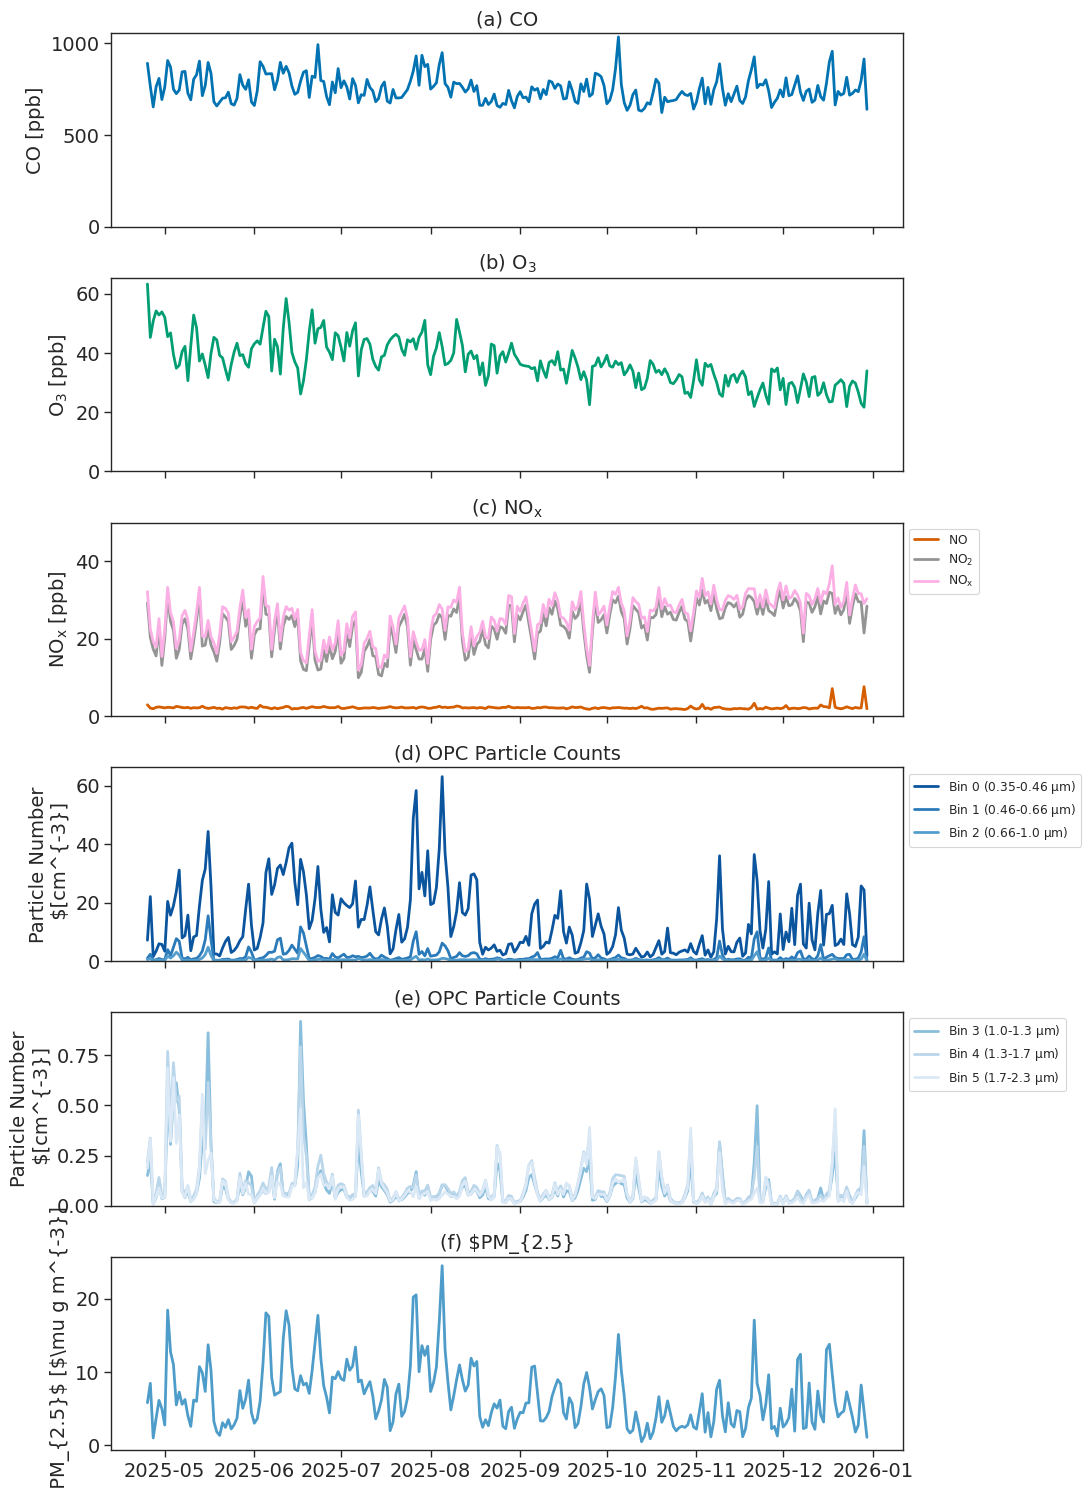

In [9]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(ts_day['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(0, None)

# plot the o3 on the second axis
ax[1].plot(ts_day['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(0, None)

#plot nox on the 2nd axis
ax[2].plot(ts_day['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(ts_day['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(ts_day['no2']+ts_day['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)


# plot the OPC bins on the 5th and 6th rows
ax[3].plot(ts_day['bin0'], lw=2, label=r'Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(ts_day['bin1'], lw=2, label=r'Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(ts_day['bin2'], lw=2, label=r'Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(ts_day['bin3'], lw=2, label=r'Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(ts_day['bin4'], lw=2, label=r'Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(ts_day['bin5'], lw=2, label=r'Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(ts_day['pm25'], lw=2, label = r'$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
ax[5].set_ylabel(r"$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(d) OPC Particle Counts", fontsize=14)
ax[4].set_title("(e) OPC Particle Counts", fontsize=14)
ax[5].set_title(r"(f) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

# force a tight layout
plt.tight_layout()

# Import the `os` module if not already imported
import os

# Create the directory if it doesn't exist
os.makedirs('MOD-00686', exist_ok=True)

fig.savefig('MOD-00686/timeseries_MOD-000686.png')

## Dirunal Plots

In [12]:
#taking daily average of ts. round to floor of the day
ts_hour = ts.groupby(ts['timestamp_local'].dt.floor('h')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_hour = ts_hour.set_index('timestamp_local')
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-04-25 10:00:00,4.000400,0.404200,0.140333,0.031000,0.032133,0.015533,3.211733,NaN,NaN,NaN,NaN,38.493333,22.946667
2025-04-25 11:00:00,3.956400,0.407800,0.134800,0.024400,0.037800,0.014400,3.164400,NaN,NaN,NaN,NaN,41.800000,22.960000
2025-04-25 13:00:00,9.554509,0.916811,0.373396,0.098302,0.155396,0.107340,7.414038,NaN,NaN,NaN,NaN,30.230189,29.173585
2025-04-25 14:00:00,8.756267,0.931000,0.395650,0.105650,0.157000,0.115800,6.628633,1099.999442,78.112923,3.435577,28.437019,30.916667,29.768333
2025-04-25 15:00:00,7.944933,0.938117,0.414350,0.119100,0.163517,0.109283,5.768033,944.429517,72.722100,4.349317,25.639800,31.466667,28.991667


In [13]:
ts_hour['pm25_c'] = 2.111 + 0.298*ts_hour['pm25'] + 0.024*ts_hour['rh'] + 0.050*ts_hour['temp']
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-04-25 10:00:00,4.000400,0.404200,0.140333,0.031000,0.032133,0.015533,3.211733,NaN,NaN,NaN,NaN,38.493333,22.946667,5.139270
2025-04-25 11:00:00,3.956400,0.407800,0.134800,0.024400,0.037800,0.014400,3.164400,NaN,NaN,NaN,NaN,41.800000,22.960000,5.205191
2025-04-25 13:00:00,9.554509,0.916811,0.373396,0.098302,0.155396,0.107340,7.414038,NaN,NaN,NaN,NaN,30.230189,29.173585,6.504587
2025-04-25 14:00:00,8.756267,0.931000,0.395650,0.105650,0.157000,0.115800,6.628633,1099.999442,78.112923,3.435577,28.437019,30.916667,29.768333,6.316749
2025-04-25 15:00:00,7.944933,0.938117,0.414350,0.119100,0.163517,0.109283,5.768033,944.429517,72.722100,4.349317,25.639800,31.466667,28.991667,6.034657


In [14]:
#prepping data
ts_hour['Hour'] = ts_hour.index.hour
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour
timestamp_local,,,,,,,,,,,,,,,
2025-04-25 10:00:00,4.000400,0.404200,0.140333,0.031000,0.032133,0.015533,3.211733,NaN,NaN,NaN,NaN,38.493333,22.946667,5.139270,10
2025-04-25 11:00:00,3.956400,0.407800,0.134800,0.024400,0.037800,0.014400,3.164400,NaN,NaN,NaN,NaN,41.800000,22.960000,5.205191,11
2025-04-25 13:00:00,9.554509,0.916811,0.373396,0.098302,0.155396,0.107340,7.414038,NaN,NaN,NaN,NaN,30.230189,29.173585,6.504587,13
2025-04-25 14:00:00,8.756267,0.931000,0.395650,0.105650,0.157000,0.115800,6.628633,1099.999442,78.112923,3.435577,28.437019,30.916667,29.768333,6.316749,14
2025-04-25 15:00:00,7.944933,0.938117,0.414350,0.119100,0.163517,0.109283,5.768033,944.429517,72.722100,4.349317,25.639800,31.466667,28.991667,6.034657,15


In [15]:
#groupping by hour and calculate the mean
diurnal_data = ts_hour.groupby('Hour').mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
Hour,,,,,,,,,,,,,,
00:00,13.949031,2.286377,0.633941,0.125143,0.129885,0.097926,6.579722,774.105007,34.088244,2.083214,25.320760,64.025756,16.890868,6.452919
01:00,13.991071,2.171874,0.560158,0.107996,0.115647,0.090329,6.382880,757.937905,33.432518,2.103510,25.131218,65.339999,16.529351,6.407726
02:00,14.049228,2.011191,0.514608,0.103321,0.114203,0.092971,6.242659,749.608567,32.875234,2.034200,25.018595,66.650541,16.176394,6.379745
03:00,14.197055,2.068296,0.525993,0.105195,0.116179,0.094921,6.121939,738.778181,32.163372,2.014564,24.495144,67.739717,15.894358,6.355809
04:00,14.430822,2.173800,0.560608,0.114245,0.125256,0.099811,6.079070,736.188895,31.287454,2.009116,24.213088,68.952297,15.585345,6.356685
05:00,14.864968,2.287022,0.601097,0.122053,0.132162,0.105466,6.084089,744.520819,29.957828,1.983647,24.766419,70.147274,15.432827,6.379234
06:00,14.739074,2.162158,0.566113,0.116367,0.129026,0.105632,6.223898,765.134873,28.944427,2.034694,25.400215,69.944469,15.451044,6.416941
07:00,14.597260,1.999798,0.520938,0.109429,0.126296,0.104425,6.552629,780.875450,29.128826,2.505954,23.268243,66.318622,16.473907,6.479026
08:00,13.914286,1.815831,0.469397,0.096164,0.116030,0.095401,6.888106,771.456104,30.703969,2.491956,19.474460,59.403249,18.649640,6.521816


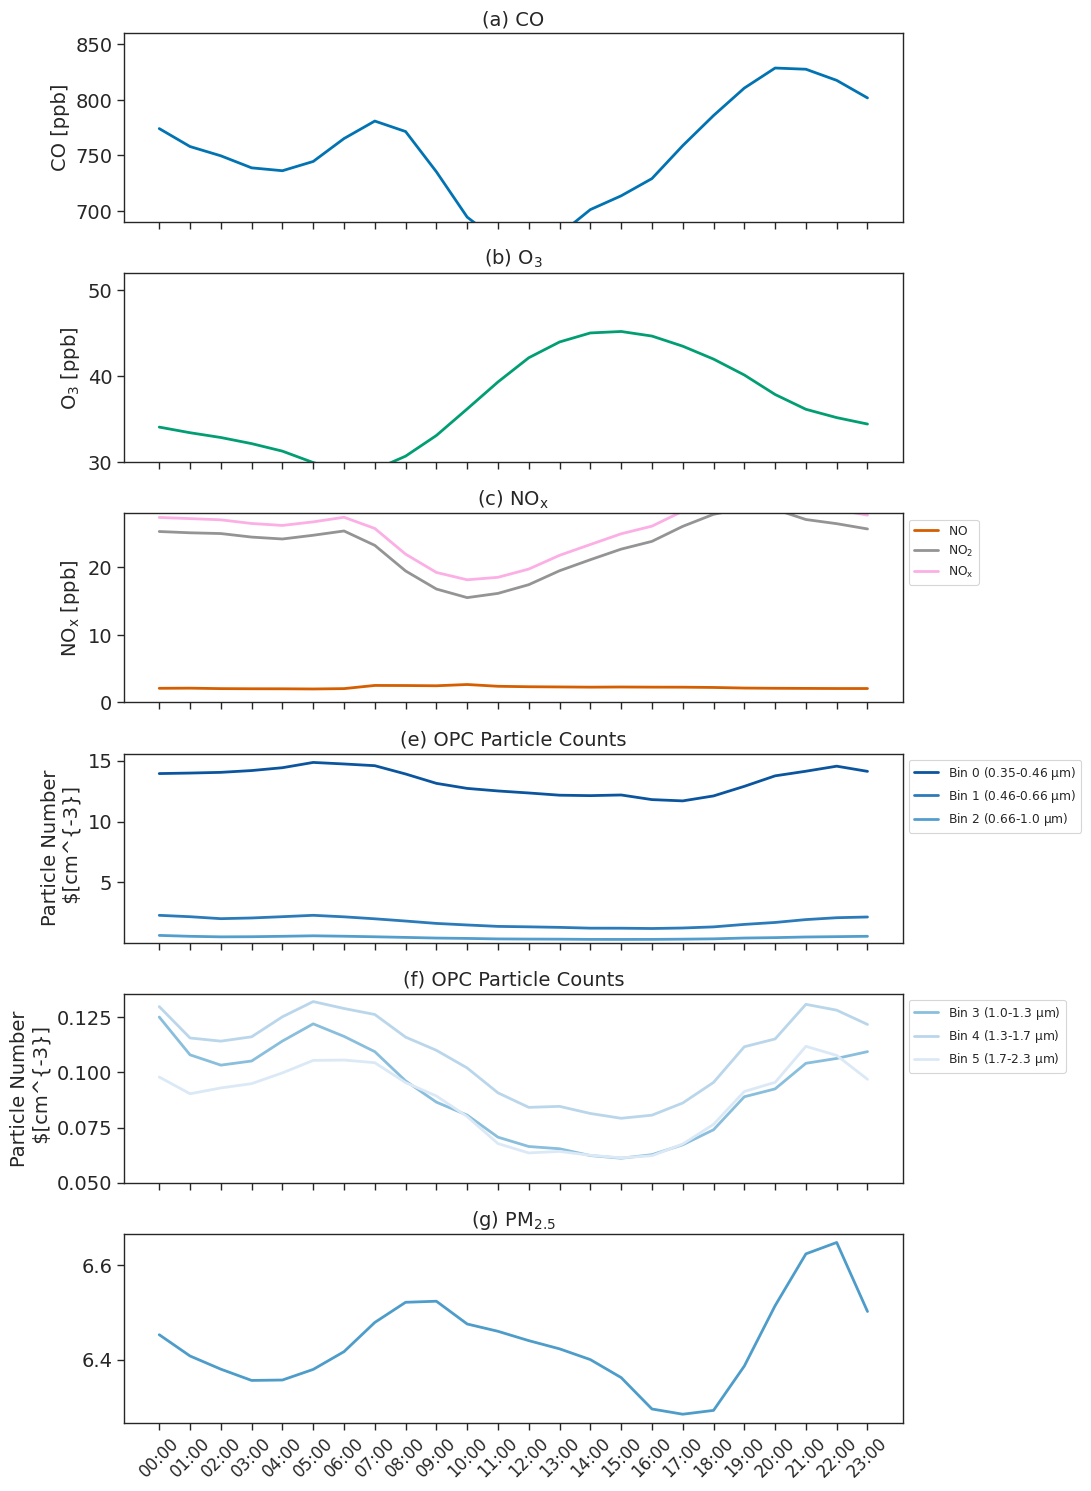

In [17]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(diurnal_data['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(690, 860)

# plot the o3 on the first axis
ax[1].plot(diurnal_data['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(30, 52)

#plot nox on the 2nd axis
ax[2].plot(diurnal_data['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(diurnal_data['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(diurnal_data['no2']+diurnal_data['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 28)

# plot the OPC bins on the 3rd and 4th rows
ax[3].plot(diurnal_data['bin0'], lw=2, label=r'Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(diurnal_data['bin1'], lw=2, label=r'Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(diurnal_data['bin2'], lw=2, label=r'Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0.05, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(diurnal_data['bin3'], lw=2, label=r'Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(diurnal_data['bin4'], lw=2, label=r'Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(diurnal_data['bin5'], lw=2, label=r'Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0.05, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(diurnal_data['pm25_c'], lw=2, label = r'$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(e) OPC Particle Counts", fontsize=14)
ax[4].set_title("(f) OPC Particle Counts", fontsize=14)
ax[5].set_title(r"(g) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# set x as hours
ax[5].set_xticks(range(24))
ax[5].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

plt.xticks(range(0, 24), size = 12)
plt.xticks(rotation=45)

# force a tight layout
plt.tight_layout()

# Import the `os` module if not already imported
import os

# Create the directory if it doesn't exist
os.makedirs('CMOD-00686', exist_ok=True)

fig.savefig('MOD-00686/dirunal_MOD-000686_allfeatures.png')

## Diurnal by Season

In [18]:
def month_to_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

In [19]:
ts_hour = ts_hour.reset_index()

In [20]:
#prepping data
ts_hour['Season'] = ts_hour['timestamp_local'].dt.month.apply(month_to_season)
ts_hour.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour,Season
0,2025-04-25 10:00:00,4.000400,0.404200,0.140333,0.031000,0.032133,0.015533,3.211733,NaN,NaN,NaN,NaN,38.493333,22.946667,5.139270,10,Spring
1,2025-04-25 11:00:00,3.956400,0.407800,0.134800,0.024400,0.037800,0.014400,3.164400,NaN,NaN,NaN,NaN,41.800000,22.960000,5.205191,11,Spring
2,2025-04-25 13:00:00,9.554509,0.916811,0.373396,0.098302,0.155396,0.107340,7.414038,NaN,NaN,NaN,NaN,30.230189,29.173585,6.504587,13,Spring
3,2025-04-25 14:00:00,8.756267,0.931000,0.395650,0.105650,0.157000,0.115800,6.628633,1099.999442,78.112923,3.435577,28.437019,30.916667,29.768333,6.316749,14,Spring
4,2025-04-25 15:00:00,7.944933,0.938117,0.414350,0.119100,0.163517,0.109283,5.768033,944.429517,72.722100,4.349317,25.639800,31.466667,28.991667,6.034657,15,Spring


In [21]:
grouped_by_season_hour = ts_hour.drop(columns='timestamp_local').groupby(['Season', 'Hour']).mean()
grouped_by_season_hour

bin0      bin1      bin2      bin3      bin4      bin5  \
Season Hour                                                                
Autumn 0      7.716595  1.293751  0.432471  0.094351  0.103500  0.081467   
       1      8.058987  1.111343  0.325736  0.068788  0.083387  0.074458   
       2      8.552427  1.104872  0.319991  0.070157  0.087162  0.079937   
       3      8.995769  1.177966  0.335788  0.073308  0.089860  0.083591   
       4      9.439092  1.287569  0.338599  0.069546  0.083120  0.074694   
...                ...       ...       ...       ...       ...       ...   
Winter 19    12.556207  1.432892  0.333421  0.053451  0.060747  0.044980   
       20    12.953455  1.522745  0.355677  0.055980  0.063868  0.046273   
       21    13.128737  1.642403  0.386830  0.063053  0.069202  0.051897   
       22    14.206732  2.032266  0.453766  0.077039  0.082675  0.061410   
       23    15.525633  2.464759  0.516543  0.081870  0.088779  0.070090   

                 pm25          co         o3        no        no2         rh  \
Season Hour                                                                    
Autumn 0     4.887385  744.936006  31.246203  2.047325  26.974161  61.837725   
       1     4.760757  737.837109  30.338532  2.091784  27.362583  63.799155   
       2     4.764403  739.302881  29.747854  1.961046  27.950367  65.347102   
       3     4.749175  728.300061  29.205873  1.950394  27.765015  66.816261   
       4     4.589908  721.193886  28.790019  2.004775  27.298204  67.872636   
...               ...         ...        ...       ...        ...        ...   
Winter 19    5.788748  759.913385  27.516637  2.075637  30.389252  56.393736   
       20    6.173526  771.952511  27.109399  2.115931  30.241895  56.848621   
       21    6.087541  761.474624  26.846413  2.115449  30.119051  57.695115   
       22    6.087785  760.570858  26.736722  2.136660  30.274997  59.333333   
       23    5.973997  758.487884  26.350301  2.273087  30.248545  61.004253   

                  temp    pm25_c  
Season Hour                       
Autumn 0     15.050417  5.804067  
       1     14.624927  5.792132  
       2     14.230046  5.810625  
       3     14.007809  5.830235  
       4     13.724055  5.793939  
...                ...       ...  
Winter 19     2.279770  5.303485  
       20     2.032126  5.416684  
       21     1.872126  5.403376  
       22     1.705460  5.434433  
       23     1.471954  5.428951  

[96 rows x 14 columns]

In [22]:
grouped_by_season_hour = grouped_by_season_hour.reset_index()
grouped_by_season_hour

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
0,Autumn,0,7.716595,1.293751,0.432471,0.094351,0.103500,0.081467,4.887385,744.936006,31.246203,2.047325,26.974161,61.837725,15.050417,5.804067
1,Autumn,1,8.058987,1.111343,0.325736,0.068788,0.083387,0.074458,4.760757,737.837109,30.338532,2.091784,27.362583,63.799155,14.624927,5.792132
2,Autumn,2,8.552427,1.104872,0.319991,0.070157,0.087162,0.079937,4.764403,739.302881,29.747854,1.961046,27.950367,65.347102,14.230046,5.810625
3,Autumn,3,8.995769,1.177966,0.335788,0.073308,0.089860,0.083591,4.749175,728.300061,29.205873,1.950394,27.765015,66.816261,14.007809,5.830235
4,Autumn,4,9.439092,1.287569,0.338599,0.069546,0.083120,0.074694,4.589908,721.193886,28.790019,2.004775,27.298204,67.872636,13.724055,5.793939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Winter,19,12.556207,1.432892,0.333421,0.053451,0.060747,0.044980,5.788748,759.913385,27.516637,2.075637,30.389252,56.393736,2.279770,5.303485
92,Winter,20,12.953455,1.522745,0.355677,0.055980,0.063868,0.046273,6.173526,771.952511,27.109399,2.115931,30.241895,56.848621,2.032126,5.416684
93,Winter,21,13.128737,1.642403,0.386830,0.063053,0.069202,0.051897,6.087541,761.474624,26.846413,2.115449,30.119051,57.695115,1.872126,5.403376
94,Winter,22,14.206732,2.032266,0.453766,0.077039,0.082675,0.061410,6.087785,760.570858,26.736722,2.136660,30.274997,59.333333,1.705460,5.434433


In [23]:
autumn_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Autumn']
winter_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Winter']
spring_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Spring']
summer_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Summer']

autumn_diurnal.index = autumn_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
winter_diurnal.index = winter_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
spring_diurnal.index = spring_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
summer_diurnal.index = summer_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))

In [24]:
autumn_diurnal

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
00:00,Autumn,0,7.716595,1.293751,0.432471,0.094351,0.103500,0.081467,4.887385,744.936006,31.246203,2.047325,26.974161,61.837725,15.050417,5.804067
01:00,Autumn,1,8.058987,1.111343,0.325736,0.068788,0.083387,0.074458,4.760757,737.837109,30.338532,2.091784,27.362583,63.799155,14.624927,5.792132
02:00,Autumn,2,8.552427,1.104872,0.319991,0.070157,0.087162,0.079937,4.764403,739.302881,29.747854,1.961046,27.950367,65.347102,14.230046,5.810625
03:00,Autumn,3,8.995769,1.177966,0.335788,0.073308,0.089860,0.083591,4.749175,728.300061,29.205873,1.950394,27.765015,66.816261,14.007809,5.830235
04:00,Autumn,4,9.439092,1.287569,0.338599,0.069546,0.083120,0.074694,4.589908,721.193886,28.790019,2.004775,27.298204,67.872636,13.724055,5.793939
05:00,Autumn,5,10.055292,1.506559,0.411397,0.080740,0.088177,0.076283,4.529595,725.736909,27.605670,1.940187,27.429653,68.976810,13.537251,5.793125
06:00,Autumn,6,10.441448,1.528512,0.404665,0.080215,0.088705,0.075724,4.692849,751.242611,26.122600,1.977045,28.506500,70.021685,13.293035,5.854641
07:00,Autumn,7,10.472808,1.348218,0.367502,0.076151,0.089421,0.075650,4.989751,776.751708,26.090567,2.025825,27.746834,67.785934,13.902381,5.919927
08:00,Autumn,8,9.688442,1.134055,0.322282,0.071709,0.091993,0.077984,5.519181,773.342919,27.604101,2.250035,23.247715,61.153956,15.846795,6.015751
09:00,Autumn,9,8.302485,0.982425,0.294151,0.066613,0.087875,0.073161,5.513112,733.588427,29.833907,2.314346,19.402866,53.810760,18.135191,5.952125


In [25]:
seasons_order = [winter_diurnal, spring_diurnal, summer_diurnal, autumn_diurnal]

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_283/3132127480.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipykernel_283/3132127480.py:41: SyntaxWarning: invalid escape sequence '\m'


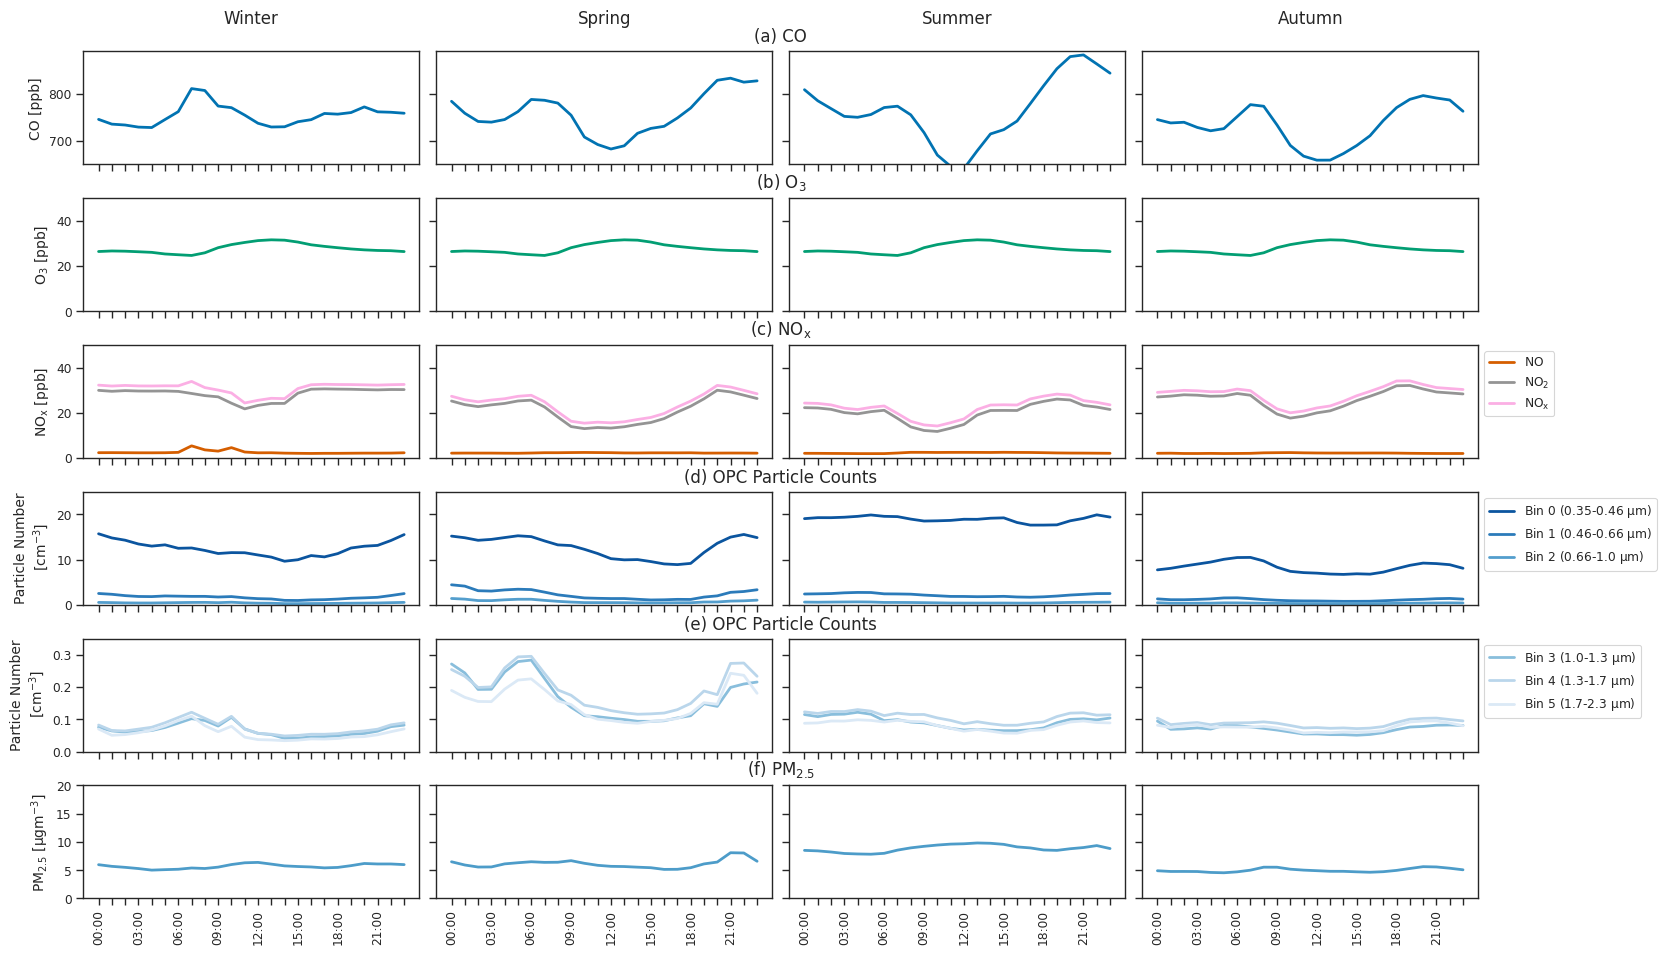

In [26]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(18,11), sharex=True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.05)

# grab the current color palette
cmap = sns.color_palette()

#iterate through seasons
for i in range(len(seasons_order)):

    #set ax column labels as season
    ax[0,0].set_title("Winter", fontsize=12, pad = 20)
    ax[0,1].set_title("Spring", fontsize=12, pad = 20)
    ax[0,2].set_title("Summer", fontsize=12, pad = 20)
    ax[0,3].set_title("Autumn", fontsize=12, pad = 20)

    # plot the CO data and label the axis
    ax[0,0].set_ylabel("CO [ppb]", fontsize=10)
    ax[0,i].plot(seasons_order[i]['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
    ax[0,i].set_ylim(650, 890)
    ax[0,i].set_xticks(range(0, 2))
    ax[0,i].set_xticks(seasons_order[i].index)

    # plot the o3 on the second axis
    ax[1,0].set_ylabel("$O_3$ [ppb]", fontsize=10)
    ax[1,i].plot(winter_diurnal['o3'], lw=2, label="$O_3$", color=cmap[2])
    ax[1,i].set_ylim(0, 50)

    #plot nox on the 3rd axis
    ax[2,0].set_ylabel("$NO_x$ [ppb]", fontsize=10)
    ax[2,i].plot(seasons_order[i]['no'], lw=2, label="$NO$", color=cmap[3])
    ax[2,i].plot(seasons_order[i]['no2'], lw=2, label="$NO_2$", color=cmap[7])
    ax[2,i].plot(seasons_order[i]['no2']+seasons_order[i]['no'], lw=2, label="$NO_x$", color=cmap[6])
    ax[2,i].set_ylim(0, 50)
    ax[2,3].legend(fontsize = 14)
    sns.move_legend(ax[2,3], "upper left", bbox_to_anchor=(1, 1))

    # plot the OPC bins on the 4th and 5th rows
    ax[3,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
    ax[3,i].plot(seasons_order[i]['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
    ax[3,i].plot(seasons_order[i]['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
    ax[3,i].set(ylim=(0, 25))
    ax[3,3].legend(fontsize = 14)
    sns.move_legend(ax[3,3], "upper left", bbox_to_anchor=(1, 1))

    ax[4,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[4,i].plot(seasons_order[i]['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
    ax[4,i].plot(seasons_order[i]['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
    ax[4,i].plot(seasons_order[i]['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
    ax[4,i].set(ylim=(0, 0.35))
    ax[4,3].legend(fontsize = 14)
    sns.move_legend(ax[4,3], "upper left", bbox_to_anchor=(1, 1))

    #plot pm25 on the 6th row
    ax[5,0].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=10)
    ax[5,i].plot(seasons_order[i]['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
    ax[5,i].set(ylim=(0, 20))
    ax[5,i].set_xticklabels(['00:00','','','03:00','','','06:00','','','09:00','','','12:00','','','15:00','','','18:00','','','21:00','',''], rotation=90)

    #remove subplot y ticks for subplots beyond winter
    if i>0:
        for j in range(6):
            ax[j,i].set_yticklabels([])

    # set titles for each panel
    row_titles = [
    "(a) CO",
    "(b) $O_3$",
    "(c) $NO_x$",
    "(d) OPC Particle Counts",
    "(e) OPC Particle Counts",
    "(f) $PM_{2.5}$"
]

for r, title in enumerate(row_titles):

    # left and right subplot positions
    left = ax[r,0].get_position()
    right = ax[r,-1].get_position()

    # horizontal center between first and last column
    x_center = (left.x0 + right.x1) / 2

    # slightly above the row
    y_top = left.y1 + 0.005

    fig.text(
        x_center,
        y_top,
        title,
        ha='center',
        va='bottom',
        fontsize=12
    )

fig.savefig('MOD-00686/diurnal_by_season_MOD-000686.png')